## Guassian Mixture Model Approach

In this notebook ill try using a gaussian mixture model to classify swing actions using a combination of:
* The output of the mediapipe pose model for each frame during an action
* Hand crafted features 
* The action length mean, variance, min & max of each keypoint


In this notebook ill be developing all of the features that I want to add beforee training my LSTM

In [1]:
import os
import ast 
import json
import shutil
import random
import cv2 as cv
import numpy as np
import pandas as pd
# import mediapipe as mp
import matplotlib.pyplot as plt

from tqdm import tqdm
from joblib import dump, load
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from classes.GraphPlotting import GraphPlotter
# from classes.GraphPlotting import GraphPlotter
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Global vars ill use throughout the file
SWING_TYPES = ["Forehand", "Backhand", "Serves", "NoStroke"]
KEYPOINTS = ['NOSE','LEFT_EYE_INNER','LEFT_EYE', 'LEFT_EYE_OUTER', 'RIGHT_EYE_INNER', 'RIGHT_EYE', 'RIGHT_EYE_OUTER', 'LEFT_EAR','RIGHT_EAR','MOUTH_LEFT', 'MOUTH_RIGHT', 'LEFT_SHOULDER','RIGHT_SHOULDER','LEFT_ELBOW','RIGHT_ELBOW','LEFT_WRIST','RIGHT_WRIST', 'LEFT_PINKY', 'RIGHT_PINKY', 'LEFT_INDEX', 'RIGHT_INDEX', 'LEFT_THUMB', 'RIGHT_THUMB', 'LEFT_HIP','RIGHT_HIP','LEFT_KNEE','RIGHT_KNEE','LEFT_ANKLE','RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'] 

## Feature Engineering

Plan of features to add:
* Delta between keypoints
* Center Torso --> Left Wrist Vector
* Center Torso --> Right Wrist Vector
* Distance between Wrists

ToDo:
* Scale samples based on pose data most in the frontal plane

Utility functions that I use throughout this script

In [2]:
def pretty_print_json(dict_object: object):
    ''' Makes JSON object prettier for being printed 
    '''
    json_object = json.dumps(dict_object)
    parsed_json = json.loads(json_object) 
    print(json.dumps(parsed_json, indent=4))


def save_JSON_object(json_path:str, json_object:object):
    ''' Saves a JSON Object to a path
    '''
    with open(json_path, 'w') as outfile:
        json.dump(json_object, outfile)


def load_JSON_object(json_path:str):
    ''' Loads JSON object from a file
    '''
    with open(json_path, "r") as f:
        json_data = json.load(f)
        return json_data


def create_folder(folder_name:str):
    '''Used to create folders
    '''
    if not os.path.exists(folder_name):
        os.mkdir(folder_name)


## Dataset Stratification

In [4]:

def get_stratified_dataset(folder_path:str, show:bool=False):
    ''' Function to build stratified dataset for testing
    '''
    file_counts = {'BH' :  [], 'FH' : [], 'NS' : [], 'SV' : []}
    all_files = os.listdir(folder_path) 
    for file in all_files:
        if "BH" in file:
            file_counts['BH'].append(file)
        elif "FH" in file:
            file_counts['FH'].append(file)
        elif "NS" in file:
            file_counts['NS'].append(file)
        elif "SV" in file:
            file_counts['SV'].append(file)


    train_files = []
    test_files = []
    # Shuffle files and build stratified train and test
    for label, files in file_counts.items():
        random.shuffle(files)
        n_train = int(0.8 * len(files))
        train_files.extend(files[:n_train])
        test_files.extend(files[n_train:])

    if show:
        print(f'Total: {len(all_files)} | Train: {len(train_files)} Test: {len(test_files)}')
        print(f'Train Head: {train_files[:5]}')
        print(f'Test Head: {test_files[:5]}')
    return train_files, test_files

# Note- Create merged dataset
merged_dataset_path = 'data/json_data/merged/'
train_files, test_files = get_stratified_dataset(merged_dataset_path, show=True)

Total: 200 | Train: 160 Test: 40
Train Head: ['BH_18.json', 'BH_12.json', 'BH_19.json', 'Mirrored_BH_6.json', 'Mirrored_BH_14.json']
Test Head: ['BH_14.json', 'BH_15.json', 'BH_17.json', 'BH_4.json', 'BH_5.json']


Convert all JSON files to pd.DataFrames so that theyre easier to manipulate

In [ ]:
def create_pose_df(json_data:object):
    ''' Create a DataFrame that more mutable for generating features
    Args:
        json_data
    '''
    pose_data_dict = {f"{kp}_{axis}": [] for kp in KEYPOINTS for axis in ("X", "Y", "Z")}

    for index, frame_data in enumerate(json_data['list_body_part_points']):
        for keypoint_dict in frame_data['key_points']:
            for axis in ['x', 'y', 'z']:
                pose_data_dict[f'{keypoint_dict["part"]}_{axis.upper()}'].append(keypoint_dict[axis])
            
    df = pd.DataFrame(pose_data_dict)
    return df



def generate_extra_keypoints(df:pd.DataFrame):
    ''' 
    '''
    # Calcualte center of hips
    df['MID_HIP_X'] = (df['RIGHT_HIP_X'] + df['LEFT_HIP_X']) / 2
    df['MID_HIP_Y'] = (df['RIGHT_HIP_Y'] + df['LEFT_HIP_Y']) / 2
    df['MID_HIP_Z'] = (df['RIGHT_HIP_Z'] + df['LEFT_HIP_Z']) / 2
    # calculate center of shoulders
    df['MID_SHOULDER_X'] = (df['RIGHT_SHOULDER_X'] + df['LEFT_SHOULDER_X']) / 2
    df['MID_SHOULDER_Y'] = (df['RIGHT_SHOULDER_Y'] + df['LEFT_SHOULDER_Y']) / 2
    df['MID_SHOULDER_Z'] = (df['RIGHT_SHOULDER_Z'] + df['LEFT_SHOULDER_Z']) / 2
    # Calculate center torso
    df['MID_CENTER_TORSO_X'] = (df['RIGHT_HIP_X'] + df['MID_SHOULDER_X']) / 2
    df['MID_CENTER_TORSO_Y'] = (df['RIGHT_HIP_Y'] + df['MID_SHOULDER_Y']) / 2
    df['MID_CENTER_TORSO_Z'] = (df['RIGHT_HIP_Z'] + df['MID_SHOULDER_Z']) / 2
    return df



def translational_invariance(df:pd.DataFrame, center_point:str ="NOSE"):
    ''' Spatially align the skeleton by re-centering all keypoints around a chosen point.
    Args:
        center_point (str): The keypoint used as the origin (default: "NOSE").
    Returns:
        pd.DataFrame: DataFrame with translationally invariant pose data.
    '''
    # Extract center coordinates
    cx = df[f"{center_point}_X"]
    cy = df[f"{center_point}_Y"]

    # Subtract center from all X and Y coordinate columns
    for col in df.columns:
        if col.endswith("_X"):
            df[col] = df[col] - cx
        elif col.endswith("_Y"):
            df[col] = df[col] - cy

    return df



def generate_deltas(df:pd.DataFrame):
    ''' Calculate the movement of each keypoint over a frame
    '''
    delta_features = {f'{col}_DELTA': df[col].diff() for col in df.columns}
    df = pd.concat([df, pd.DataFrame(delta_features)], axis=1)
    # Fill first diff row with 0's
    df = df.fillna(0)
    return df



def calculate_velocities(df:pd.DataFrame, fps:float =30.0):
    ''' Take the created delta cols and convert them to velocities
    Args:
        df (DataFrame) : DF containing all feature and KP cols
        fps (Float) : frame per second of video standardised to 30
    Returns:
        df (DataFrame) : df
    '''
    # Get all delta cols & calculate velocity for each of them
    delta_cols = [col for col in df.columns if col.endswith('_DELTA')]
    vel = df[delta_cols] * fps
    vel.columns = [col.replace('_DELTA', '_VELO') for col in vel.columns]
    df = pd.concat([df, vel], axis=1)
    return df


def calculate_acceleration(df:pd.DataFrame, fps:float =30.0):
    ''' Calculate Acceleration from velocities
    '''
    velo_cols = [col for col in df.columns if col.endswith('_VELO')]
    acc = df[velo_cols].diff() * fps
    acc.columns = [c.replace('_VELO', '_ACC') for c in acc.columns]
    df = pd.concat([df, acc.fillna(0)], axis=1)
    return df



def calculate_vector_direction(df:pd.DataFrame, origin_kp:str, traget_kp:str):
    ''' Calculate the direction of the vector from the center of the wrist to each torso
    Args:
        df (DataFrame) : X,Y,Z DF
        origin_kp (String) : kp1
        traget_kp (String) : kp2
    Returns:
        df (DataFrame) : DF with updated cols
    '''
    wrist_side = traget_kp.split('_')[0]
    # Get diffs from origin to target
    dx = df[f'{traget_kp}_X'] - df[f'{origin_kp}_X']
    dy = df[f'{traget_kp}_Y'] - df[f'{origin_kp}_Y']
    dz = df[f'{traget_kp}_Z'] - df[f'{origin_kp}_Z']

    # Vector magnitude (per frame)
    mag = np.sqrt(dx**2 + dy**2 + dz**2)
    # Vector overlap
    mag = mag.replace(0, np.nan)

    # Direction unit vector components
    df[f'DIR_TORSO_{wrist_side}_WRIST_X'] = dx / mag
    df[f'DIR_TORSO_{wrist_side}_WRIST_Y'] = dy / mag
    df[f'DIR_TORSO_{wrist_side}_WRIST_Z'] = dz / mag
    # NOTE - This might be better because its rotation invariant 
    # azimuth = np.degrees(np.arctan2(dy, dx))
    # elevation = np.degrees(np.arctan2(dz, np.hypot(dx, dy)))
    # df[f'DIR_{kp1}_WRIST_AZIMUTH'] = azimuth
    # df[f'DIR_{kp1}_{kp2}_ELEVATION'] = elevation
    return df


def get_most_front_plane(df:pd.DataFrame):
    ''' 
    '''
    df['HIP_Z_DIFF'] = (df["RIGHT_HIP_Z"] - df["LEFT_HIP_Z"]).abs()
    df['SHOULDER_Z_DIFF'] = (df["RIGHT_SHOULDER_Z"] - df["LEFT_SHOULDER_Z"]).abs()
    df['AVG_Z_DIFF'] = (df['HIP_Z_DIFF'] + df['SHOULDER_Z_DIFF']) / 2

    gp = GraphPlotter('')
    min_diff = df['AVG_Z_DIFF'].min()
    min_idx = df['AVG_Z_DIFF'].idxmin()
    print(min_diff)
    print(min_idx)
    gp.plot_kp_over_time({'AVG_Z_DIFF' : df['AVG_Z_DIFF']}, 'AVG_Z_DIFF')
    print("-"* 50)
    
    return df



def scale_invariance(df:pd.DataFrame, ref:str ='both'):
    ''' Usede to scale all skeletons to the same size
    Args:
        
    '''
    df = get_most_front_plane(df)



def calculate_torso_to_wrist_vector(df:pd.DataFrame):
    ''' Calculate the direction of the vector from the center of the torso to each arm
    '''
    df = calculate_vector_direction(df, 'MID_CENTER_TORSO', 'LEFT_WRIST')
    df = calculate_vector_direction(df, 'MID_CENTER_TORSO', 'RIGHT_WRIST')
    return df



def calculate_wrist_distance(df:pd.DataFrame):
    ''' Calculate the distance between the wrists
    '''
    df['WRIST_DIST_X'] = abs(df['RIGHT_WRIST_X'] - df['LEFT_WRIST_X'])
    df['WRIST_DIST_Y'] = abs(df['RIGHT_WRIST_X'] - df['LEFT_WRIST_X'])
    # 2D euclidean distance
    df['WRIST_EUCLID_DIST'] = np.sqrt((df['RIGHT_WRIST_X'] - df['LEFT_WRIST_X'])**2 + (df['RIGHT_WRIST_Y'] - df['LEFT_WRIST_Y'])**2)
    return df


def generate_features(file_path:str, subset_cols:list, show_df_dims:bool = False):
    ''' This is goignt o be the main function where i generate all my feature for a given file from
    Args:
        file_path (String) : String file path to JSON file we want ot generate features for 
        subset_cols (List) : List of keypoints that will be removed
    '''
    # print('File Path:', file_path)
    json_data = load_JSON_object(file_path)
    
    # Convert dict to DF
    df = create_pose_df(json_data)
    
    # Generate all extra keypoints that I think will be useful for when I start training or that can be used to generate features
    df = generate_extra_keypoints(df)

    # Center origin around pose skeleton
    df = translational_invariance(df, center_point='MID_HIP')

    # NOTE - Used for scaling the skeleton
    # scale_invariance(df, ref='both')
    # df = get_most_front_plane(df)

    # Calculate keypoint movement between frames
    df = generate_deltas(df)

    # Calculate velocities
    df = calculate_velocities(df, fps=30)

    df = calculate_acceleration(df, fps=30)

    # calculate the distance between wrists -  should help with splitting 
    df = calculate_wrist_distance(df)

    # Calculate direction of vectors from center of the torso to each wrist
    df = calculate_torso_to_wrist_vector(df)

    # Remove any cols I dont want to be included when forming the GMM's
    if subset_cols:
        cols_to_remove = get_cols_to_remove(df)
        df = df[[i for i in df.columns if i not in cols_to_remove]]
    
    # COnvert to numpy array
    feature_array = df.to_numpy(dtype=np.float32)
    feature_array = np.nan_to_num(feature_array, nan=0.0, posinf=0.0, neginf=0.0)
    if show_df_dims:
        print(df)
        print(f'Num Frames: {len(df)}')
        print(f'Num Columns: {len(df.columns)}')
        print(f'Array Shape: {feature_array.shape}')

    return feature_array, df.columns


def get_cols_to_remove(df:pd.DataFrame):
    ''' Removing columns i think wont be actually useful for generating GMM's
    '''
    # nonimportant_keypoints = ['NOSE', 'EYE', 'THUMB', 'MOUTH', 'EAR', 'PINKY', 'THUMB', 'INDEX', 'HEEL', 'FOOT', 'ANKLE', 'KNEE']
    nonimportant_keypoints = ['NOSE', 'EYE', 'THUMB', 'MOUTH', 'EAR', 'PINKY', 'THUMB', 'INDEX', 'HEEL', 'FOOT', 'ANKLE', 'KNEE', '_DELTA']
    cols_to_remove = [i for i in df.columns if '_Z' in i or any(substr in i for substr in nonimportant_keypoints)]
    return cols_to_remove



def create_action_JSON_dataset(files_list:list, base_folder:str, output_folder:str, output_file_name:str, desc:str='Working...'):
    ''' Takes a list of files and opens their JSON files and creates a series ofgenerated features to add
    Args:
        files_list (List) : List of files we want to generate features for 
        base_folder (String) : File path to folder containing all JSON files for all file name sin files_list
        output_folder (String) : String file path to folder we want to save the output JSON file to
        file_name (String) : Name of output file
        desc (String) : Description for tqdm
    Returns:
        col_list (List) : List of cols that will  be used further down
        saves JSON file where {K = swing_type : V = {file_name : np.ndarray of data}}
    '''
    # List of cols
    col_list = []

    # Create folder to store all numpy arrays and features
    create_folder(output_folder)
    # Function for building all features ill be using as a base for all of my models 
    train_data = {'Backhand' :  {}, 'Forehand' : {}, 'Serves' : {}, 'NoStroke' : {}}
    for file_name in tqdm(files_list, desc=desc):
        # Create feature columns and return as numpy array with list of remaining columns
        
        feat_array, col_list = generate_features(f'{base_folder}{file_name}', subset_cols=True, show_df_dims=False)
        
        # Save it an npy/npz files instead of converting to string just to convert back in the next cell like GMM
        # json_str = json.dumps(feat_array.tolist())
        if "BH" in file_name:
            train_data['Backhand'][file_name] = feat_array
        elif "FH" in file_name:
            train_data['Forehand'][file_name] = feat_array
        elif "SV" in file_name:
            train_data['Serves'][file_name] = feat_array
        elif "NS" in file_name:
            train_data['NoStroke'][file_name] = feat_array

    for swing_type, swing_data in train_data.items():
        np.savez_compressed(f'{output_folder}{swing_type}.npz', swings=np.array(swing_data, dtype=object))
    
    return col_list


# NOTE - Creates JSON file in output_folder where K == action and V == dict where {K == file && V == np.ndarray of pose data} 
col_list = create_action_JSON_dataset(files_list=train_files, 
                           base_folder='data/json_data/merged/', 
                           output_folder='data/json_data/npz/', 
                           output_file_name='train_files.json')

Working...: 100%|██████████| 160/160 [00:06<00:00, 26.12it/s]


## Building Gaussian mixture models for each action

Below Im going to build a gaussian mixture model for eahc class that I will use as a base for my comparison

                        feature  mean_abs_loading  relative_importance
0   mean_DIR_TORSO_LEFT_WRIST_X          0.094108             1.000000
1         var_LEFT_ELBOW_Y_VELO          0.088658             0.942093
2       min_MID_SHOULDER_X_VELO          0.087205             0.926649
3         mean_RIGHT_HIP_Y_VELO          0.085709             0.910754
4          mean_LEFT_HIP_Y_VELO          0.085709             0.910753
5      min_RIGHT_SHOULDER_Y_ACC          0.085665             0.910286
6       mean_RIGHT_ELBOW_Y_VELO          0.082343             0.874983
7    var_DIR_TORSO_LEFT_WRIST_Y          0.081831             0.869547
8          min_LEFT_ELBOW_X_ACC          0.080934             0.860018
9        min_RIGHT_ELBOW_Y_VELO          0.080722             0.857765
10         min_RIGHT_HIP_Y_VELO          0.080193             0.852139
11      mean_RIGHT_WRIST_Y_VELO          0.079355             0.843234
12       mean_LEFT_WRIST_Y_VELO          0.077923             0.828018
13    

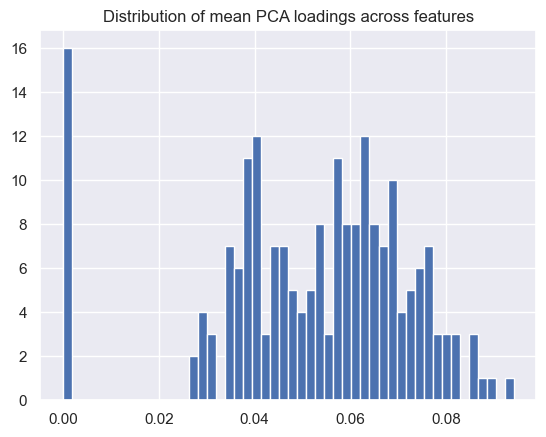

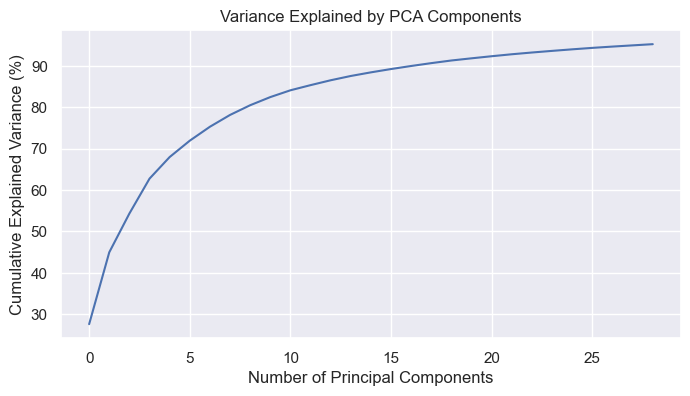

Samples: 160 | Original features: 204 | PCs kept: 29
Forehand: Best k=3, cov=diag, BIC=2865.40
Backhand: Best k=4, cov=diag, BIC=3289.10
Serves: Best k=4, cov=diag, BIC=2941.67
NoStroke: Best k=3, cov=diag, BIC=6729.05


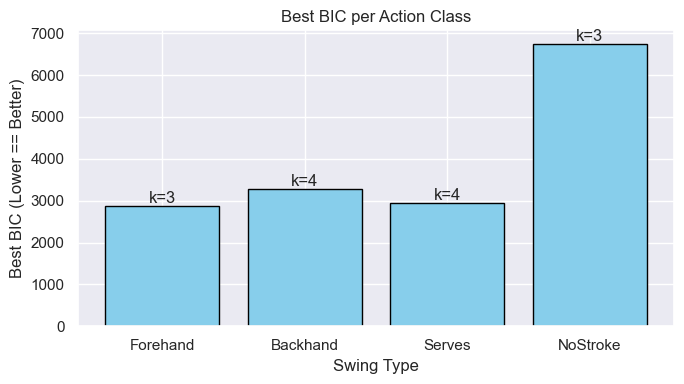

In [ ]:
''' 
    Links:
        mixture model : https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html
        v stack : https://www.geeksforgeeks.org/python/numpy-vstack-in-python/
        PCS variance : https://medium.com/@sahin.samia/principal-component-analysis-pca-made-easy-a-complete-hands-on-guide-e26a3680c0bc

'''

from collections import defaultdict


def fit_scaler(data:np.ndarray):
    # Sclaing data based on all of it
    scaler = StandardScaler().fit(data)
    return scaler


def build_expanded_feature_names(base_names:list, include_velocity=True):
    stats = ["mean", "var", "min", "max"]
    # if include_velocity:
    #     stats += ["vel_mean", "vel_var"]
    # Building 888 size column names to match X_data
    expanded = [f"{stat}_{name}" for stat in stats for name in base_names]
    return expanded


def calculate_action_summaries(feat_array:np.ndarray):
    ''' Calculate the mean, variance, min and max for all columns for each sample
    Args:
        feat_array (np.ndarray) : 1 repetition of an action
    Returns:
        means, vars, mins, maxs
    '''
    # Calculate  column stats
    means = feat_array.mean(axis=0)
    vars = feat_array.var(axis=0)
    mins = feat_array.min(axis=0)
    maxs = feat_array.max(axis=0)
    return np.concatenate([means, vars, mins, maxs])



def build_swing_action_dataset(json_file_path:str, swing_types:list):
    ''' Function to build the dataset that ill feed into the gmms
    Args:
        array_folder_path (String) : String file path to folder containing all json data
        swing_types (List) : List of actions
    '''
    X_train = []
    y_train = []
    swing_dict = {}

    json_data = load_JSON_object(json_file_path)
    for swing_type in swing_types:
        swing_data = json_data[swing_type]
        summaries = []
        for _, array_str in swing_data.items():
            # Loading pose array from JSON
            feature_array = ast.literal_eval(array_str)
            feature_array = np.nan_to_num(feature_array)
            X = np.array(feature_array, dtype=np.float32)
            # Get overall statistics of movement
            s = calculate_action_summaries(X)
            summaries.append(s)

        summary_vert = np.vstack(summaries)
        swing_dict[swing_type] = summary_vert
        X_train.append(summary_vert)
        # extend labels with one label per clip in this class
        y_train.extend([swing_type] * summary_vert.shape[0])

    # Final stacks
    X_data = np.vstack(X_train)
    y_train = np.array(y_train) 

    return swing_dict, X_data, y_train


def fit_GMM_to_actions(swing_dict:dict, scaler:StandardScaler, pca:PCA, n_components_options:list =[1, 2, 3, 4], cov_types:list =['diag'], reg_covar:float =1e-3, random_state:int =RANDOM_STATE):
    '''Fit one global StandardScaler and PCA, then a per-class Gaussian Mixture Model (GMM) with BIC-based model selection for each swing type.
    Args:
        swing_dict (dict): Dictionary where K == swing type & V == vertically stacked clip summaries
        scaler (StandardScaler): Fitted scaler used to normalize data 
        pca (PCA): Fitted PCA object for dimensionality reduction before fitting GMMs
        n_components_options (List): List of number of mixtures to try
        cov_types (List): Covariance types to try
        reg_covar (float): Regularization term added to the diagonal of covariance matrices to make it more stable
        random_state (int): Random seed
    Returns:
        scaler (StandardScaler): The same fitted scaler passed in
        mixtures_dict (dict): {swing_label: best_fitted_GaussianMixture}
        results_dict (dict): {swing_label: {"bic": best_bic, "k": n_components, "cov": covariance_type}}
    '''
    results_dict = {}
    mixtures_dict = {}

    # Iterate over each swing type (class)
    for swing_label, X_train in swing_dict.items():
        # Scale swing data to same scale as global dataset
        X_scaled = scaler.transform(X_train)
        # Apply PCA transformation for dimensionality reduction
        X_reduced = pca.transform(X_scaled)
        # Convert to float64 for numerical stability
        X_reduced = X_reduced.astype(np.float64)

        # Track all trials so we can plot BIC vs k later
        trial_k_list   = []
        trial_bic_list = []
        trial_cov_list = []
        best_model = None
        best_bic = np.inf  # initialize with infinity for comparison

        # Loop through all covariance types and number of components to find best model
        for cov_type in cov_types:
            for n_components in n_components_options:
                # Initialize and fit GMM for current config
                mixture_model = GaussianMixture(n_components=n_components, covariance_type=cov_type, reg_covar=reg_covar, init_params="kmeans", n_init=5, max_iter=500, random_state=random_state)
                mixture_model.fit(X_reduced)
                bic_value = mixture_model.bic(X_reduced)

                # Store all atytempts for plotting
                trial_k_list.append(n_components)
                trial_bic_list.append(float(bic_value))
                trial_cov_list.append(cov_type)

                # Update if this model has a lower BIC (better balance of fit vs complexity)
                if bic_value < best_bic:
                    best_model, best_bic = mixture_model, bic_value

        # Aggregate to best BIC per k (across covariance types) for a clean BIC-vs-k curve
        bic_per_k = defaultdict(list)
        for k, bic, cov in zip(trial_k_list, trial_bic_list, trial_cov_list):
            bic_per_k[k].append(bic)

        k_list   = sorted(bic_per_k.keys())
        bic_list = [min(bic_per_k[k]) for k in k_list]

        # Store best results for each model
        mixtures_dict[swing_label] = best_model
        results_dict[swing_label] = {
            "bic": float(best_bic),
            "k": int(best_model.n_components),
            "cov": best_model.covariance_type,
            "reg_covar": reg_covar,
            "k_list": k_list,
            "bic_list": bic_list,
            "trial_k_list": trial_k_list,
            "trial_bic_list": trial_bic_list,
            "trial_cov_list": trial_cov_list
        }

        print(f'{swing_label}: Best k={best_model.n_components}, cov={best_model.covariance_type}, BIC={best_bic:.2f}')
    return scaler, mixtures_dict, results_dict



def display_most_influential_features(components, col_list:list, show_dist:bool =False):
    ''' 
    '''
    # Magnitudes of contribution to variance
    abs_mags = np.abs(components)
    # Average loading across all components 
    mean_loading = abs_mags.mean(axis=0)
    # Rank features by importance
    top_features_idx = np.argsort(mean_loading)[::-1]  # descending
    top_features = [(col_list[i], mean_loading[i]) for i in top_features_idx[:20]]
    df = pd.DataFrame(top_features, columns=["feature", "mean_abs_loading"])
    # Normalise importance
    df["relative_importance"] = df["mean_abs_loading"] / df["mean_abs_loading"].max()

    if show_dist:
        print(df)
        df.to_csv('data/csv/GMM_Feature_importance.csv')
        plt.hist(mean_loading, bins=50)
        plt.title("Distribution of mean PCA loadings across features")
        plt.show()
    return df

    


def PCA_feature_analysis(X_data: np.ndarray, scaler:StandardScaler, col_list:list, variance_percentile:float =0.95, top_n:int =50, show_important_features:bool =True, show_var_ratio:bool =False):
    ''' Function for component analysis and to see how useful each feature actually is 
    Args:
        x_data (ndarray) : All X data
        scaler (StandardScaler) : scaler for x_data
        top_n (Int) : The top N features that we want to keep
        show_var_ratio (Bool) : Plot variance ratio or not
    '''
    X_scaled = scaler.transform(X_data)

    if variance_percentile:
        pca = PCA(n_components=variance_percentile, random_state=RANDOM_STATE)
        X_reduced = pca.fit_transform(X_scaled)
        kept = pca.n_components_
        if show_important_features:
            pca_df = display_most_influential_features(pca.components_, col_list, show_dist=True)
    else:
        pca = PCA(n_components=top_n, random_state=RANDOM_STATE)
        X_reduced = pca.fit_transform(X_scaled)
        kept = top_n
        if show_important_features:
            pca_df = display_most_influential_features(pca.components_, col_list, show_dist=True)

    # Plot variance ratio
    if show_var_ratio:
        plt.figure(figsize=(8,4))
        plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100)
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Cumulative Explained Variance (%)')
        plt.title('Variance Explained by PCA Components')
        plt.grid(True)
        plt.show()
        plt.close()

    n_samples, n_feat = X_data.shape
    print(f'Samples: {n_samples} | Original features: {n_feat} | PCs kept: {kept}')
    return scaler, pca, X_reduced, pca_df



# def plot_BIC_hist(results_dict:dict):
#         ''' Plots the Bayesian Information criterion for each all most important features
#         Args:
#             results_dict
#         '''
#         swing_types = list(results_dict.keys())
#         bics = [res['bic'] for res in results_dict.values()]
#         ks = [res['k'] for res in results_dict.values()]
#         plt.figure(figsize=(7, 4))
#         bars = plt.bar(swing_types, bics, color='skyblue', edgecolor='black')
#         plt.xlabel("Swing Type")
#         plt.ylabel("Best BIC (Lower == Better)")
#         plt.title("Best BIC per Action Class")

#         # Annotate bars with k values
#         for bar, k in zip(bars, ks):
#             plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
#                     f"k={k}", ha='center', va='bottom')

#         plt.tight_layout()
#         plt.show()




def gaussian_mixture_main(feature_names:list, train_file_path:str):
    ''' Main functrion for building gaussian mixture models that will be used as a baseline for comparison against my other models
    '''
    # Build action dataset from saved numpy array objects
    swing_dict, X_data, y_data = build_swing_action_dataset(train_file_path, SWING_TYPES)
    # Get inflated list of column names o keep in line with calculate_action_summaries()
    expanded_col_list = build_expanded_feature_names(feature_names, include_velocity=True)
    # calculate scaler for data
    scaler = fit_scaler(X_data)
    # Remove useless features
    scaler, pca, X_reduced, pca_df = PCA_feature_analysis(X_data, scaler, expanded_col_list, variance_percentile=0.95, show_var_ratio=True)
    # Find best mixture model to suit each swing type 
    scaler,  mixtures_dict, results_dict = fit_GMM_to_actions(swing_dict, scaler, pca, random_state=RANDOM_STATE)
    
    # Plot BIC differences between mixtures
    # plot_BIC_hist(results_dict)
    gp = GraphPlotter(train_file_path)
    gp.plot_BIC_hist(results_dict)
    # Save scale, pca, models from trianing in pickle
    create_folder('data/models/')
    dump({
        'scaler': scaler,
        "pca": pca,
        'mixtures' : mixtures_dict,
        'feature_names' : pca_df.columns,
        'results_dict' : results_dict,
        'pca_df' : pca_df,
    }, "data/models/tennis_mixture_models.pkl")
    
    return mixtures_dict, results_dict
        

mixtures_dict, results_dict = gaussian_mixture_main(col_list, train_file_path='data/json_data/numpy_feature_arrays/train_files.json')


Analysis of results and inference

Generating features for Test files:   0%|          | 0/40 [00:00<?, ?it/s]

Generating features for Test files: 100%|██████████| 40/40 [00:01<00:00, 26.18it/s]



Test Accuracy: 92.50
Class Priors:
Forehand: 0.20
Backhand: 0.20
Serves: 0.20
NoStroke: 0.40

Detailed Classification Report:
              precision    recall  f1-score   support

    Backhand      1.000     0.875     0.933         8
    Forehand      1.000     0.750     0.857         8
    NoStroke      0.842     1.000     0.914        16
      Serves      1.000     1.000     1.000         8

    accuracy                          0.925        40
   macro avg      0.961     0.906     0.926        40
weighted avg      0.937     0.925     0.924        40

Average log-likelihood per class:
Forehand   -95.049
Backhand   -80.931
Serves     -190.976
NoStroke   -58.871


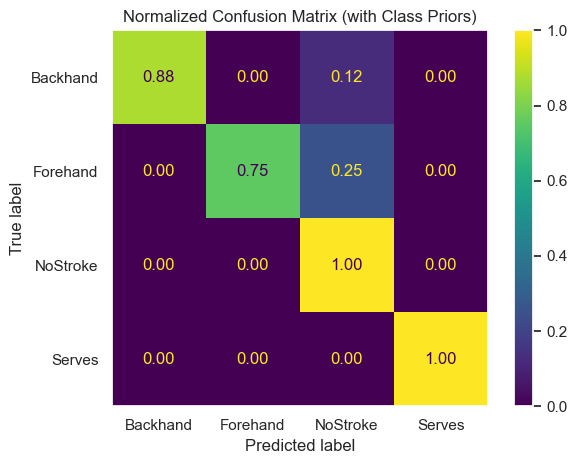

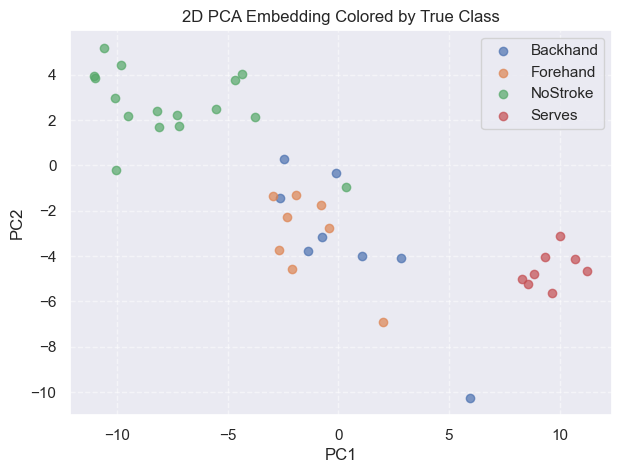

                        feature  mean_abs_loading  relative_importance  \
0   mean_DIR_TORSO_LEFT_WRIST_X          0.094108             1.000000   
1         var_LEFT_ELBOW_Y_VELO          0.088658             0.942093   
2       min_MID_SHOULDER_X_VELO          0.087205             0.926649   
3         mean_RIGHT_HIP_Y_VELO          0.085709             0.910754   
4          mean_LEFT_HIP_Y_VELO          0.085709             0.910753   
5      min_RIGHT_SHOULDER_Y_ACC          0.085665             0.910286   
6       mean_RIGHT_ELBOW_Y_VELO          0.082343             0.874983   
7    var_DIR_TORSO_LEFT_WRIST_Y          0.081831             0.869547   
8          min_LEFT_ELBOW_X_ACC          0.080934             0.860018   
9        min_RIGHT_ELBOW_Y_VELO          0.080722             0.857765   
10         min_RIGHT_HIP_Y_VELO          0.080193             0.852139   
11      mean_RIGHT_WRIST_Y_VELO          0.079355             0.843234   
12       mean_LEFT_WRIST_Y_VELO       

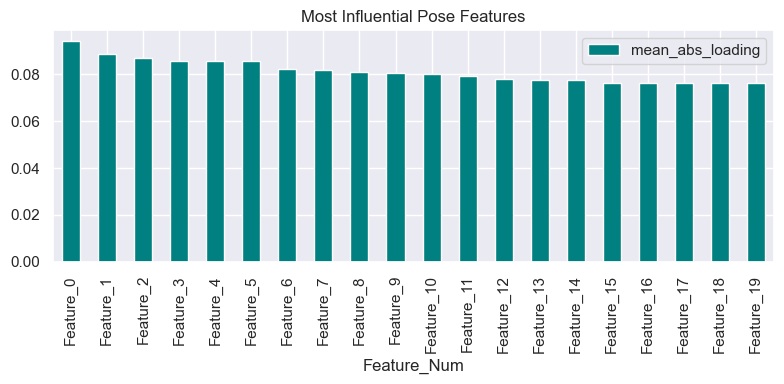

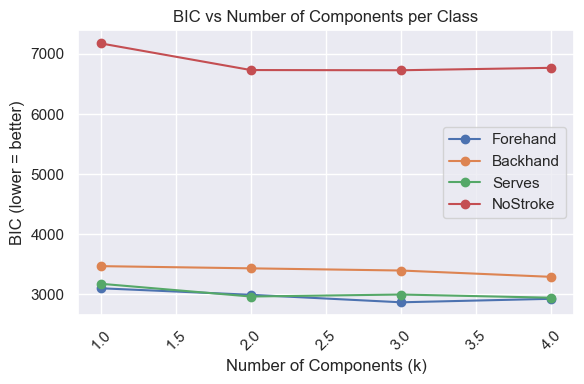

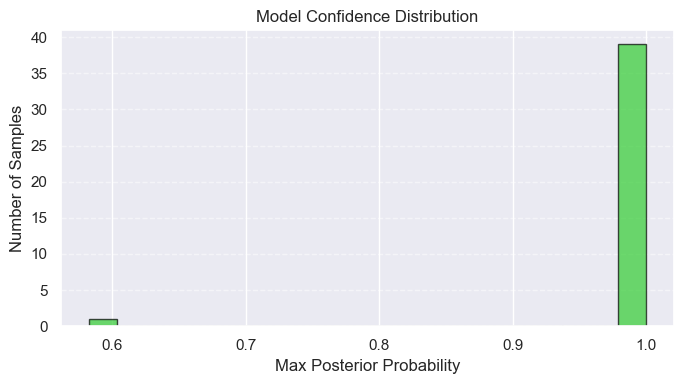

[[2.79723330e-09 9.99999716e-01 2.28398474e-55 2.81183630e-07]
 [1.13056983e-12 9.99999949e-01 3.90767454e-60 5.09422395e-08]
 [6.18726596e-21 1.00000000e+00 4.53143791e-72 2.45120822e-12]
 [2.00463999e-08 9.99994382e-01 8.10875492e-59 5.59753922e-06]
 [4.84304530e-42 1.41829913e-38 3.00337883e-91 1.00000000e+00]
 [3.97518879e-24 9.99999849e-01 1.94514136e-79 1.51472299e-07]
 [2.67597190e-16 9.99997836e-01 5.74860682e-53 2.16429829e-06]
 [1.65261432e-15 9.99999953e-01 1.02101500e-60 4.66067657e-08]]
[[4.17740642e-01 2.90445227e-17 1.52783410e-32 5.82259358e-01]
 [2.06726924e-12 1.88121138e-10 7.43453748e-91 1.00000000e+00]
 [9.99999607e-01 3.91465414e-07 6.35247235e-44 1.20312120e-09]
 [9.99995839e-01 3.86205541e-06 2.74436527e-47 2.98695125e-07]
 [9.99970200e-01 8.16873618e-07 5.62834487e-72 2.89828322e-05]
 [9.99999871e-01 3.46555145e-08 2.97719288e-70 9.44882121e-08]
 [9.99999984e-01 1.38394398e-08 5.09700174e-49 2.04883494e-09]
 [9.99982151e-01 1.54802020e-05 2.98467212e-42 2.36858

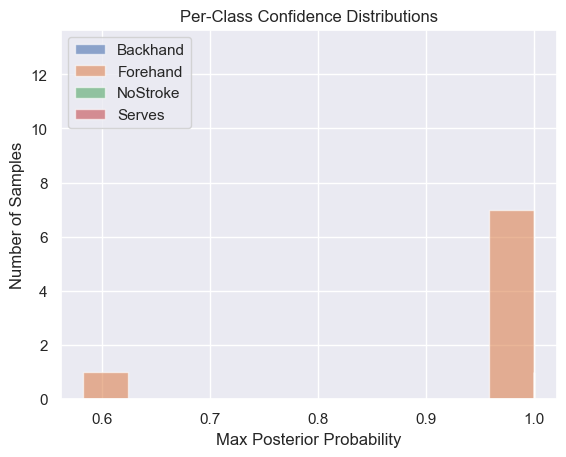

{'accuracy': 0.925,
 'priors': {'Forehand': 0.2, 'Backhand': 0.2, 'Serves': 0.2, 'NoStroke': 0.4},
 'pred_labels': ['NoStroke',
  'NoStroke',
  'Forehand',
  'Forehand',
  'Forehand',
  'Forehand',
  'Forehand',
  'Forehand',
  'Backhand',
  'Backhand',
  'Backhand',
  'Backhand',
  'NoStroke',
  'Backhand',
  'Backhand',
  'Backhand',
  'Serves',
  'Serves',
  'Serves',
  'Serves',
  'Serves',
  'Serves',
  'Serves',
  'Serves',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke',
  'NoStroke'],
 'scores': [{'Forehand': -64.13912407936654,
   'Backhand': -101.34393132386,
   'Serves': -136.52510142955722,
   'NoStroke': -63.80706886462182},
  {'Forehand': -86.30405986266658,
   'Backhand': -81.79320228740626,
   'Serves': -266.9283743681355,
   'NoStroke': -59.39926727541189},
  {'Forehand': -36.513712192169294,
   'Backhand': -51

In [ ]:
from scipy.special import softmax
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, recall_score, f1_score, precision_score, confusion_matrix


def load_mixtures(pkl_path:str):
    ''' Load a pickle file containing scaler, PCA, mixtures and
    '''
    model_bundle = load(pkl_path)
    scaler = model_bundle["scaler"]
    pca = model_bundle["pca"]
    mixtures_dict = model_bundle["mixtures"]
    results_dict = model_bundle["results_dict"]
    pca_df = model_bundle['pca_df']
    feature_names = model_bundle["feature_names"]
    return scaler, pca, mixtures_dict, results_dict, pca_df, feature_names




def create_numpy_feature_arrays(folder_path, output_folder_path):
    ''' Takes a folder as input and creates a series of json object where K == swing_type and V == { K == uid && V == str(np.ndarray of pose data)}
    Args:
        folder_path (string) :
        output_folder_path (String) : 
    '''
    for swing_type in os.listdir(folder_path):
        swing_data = {}
        for file in tqdm(os.listdir(f'{folder_path}{swing_type}'), desc= f'Generating features for {swing_type}'):
            # Create feature columns and return as numpy array with list of remaining columns
            feat_array, col_list = generate_features(f'{folder_path}{swing_type}/{file}', subset_cols=True)

            # Convert to string to i can save it 
            json_str = json.dumps(feat_array.tolist())
            swing_data[file.replace('.json', '')] = json_str
        
        save_JSON_object(f'data/json_data/numpy_feature_arrays/{swing_type}.json', swing_data)



def testset_preprocessing(test_folder_path, scaler, pca, eps=1e-12):
    ''' 
    '''
    # Preprocessing X_test & y_test
    swing_dict, X_test, y_test = build_swing_action_dataset(test_folder_path, SWING_TYPES)
    X_test_scaled = scaler.transform(X_test)
    X_test_pca = pca.transform(X_test_scaled)

    # Calculating and smoothing class priors
    class_counts = {label: X.shape[0] for label, X in swing_dict.items()}
    total = sum(class_counts.values())
    priors = {label: count / total for label, count in class_counts.items()}
    log_priors = {lbl: np.log(max(p, eps)) for lbl, p in priors.items()}
    return X_test_pca, y_test, priors, log_priors



def inference_test_main(scaler:StandardScaler, pca:PCA, mixtures_dict:dict, results_dict:dict, pca_df:pd.DataFrame, test_folder_path:str):
    ''' Main function for loading test set,,inferencing and evalauting results
    Args:
        scaler (StandardScaler) : 
        pca (PCA) : 
        mixtures_dict (dict) : 
        test_folder_path (str) :
    '''
    # Scale test data the same as train data
    X_test_pca, y_test, priors, log_priors = testset_preprocessing(test_folder_path, scaler, pca)

    # Inference test dataset 
    pred_labels = []
    all_scores = []
    for x in X_test_pca:
        class_scores = {}
        for label, gmm in mixtures_dict.items():
            log_likelihood = gmm.score_samples([x])[0]
            log_posterior = log_likelihood + log_priors[label]
            class_scores[label] = log_posterior
            # 

        best_label = max(class_scores, key=class_scores.get)
        pred_labels.append(best_label)
        all_scores.append(class_scores)



    # Evaluate class accuracy
    acc = accuracy_score(y_test, pred_labels)
    print(f"\nTest Accuracy: {(acc * 100):.2f}")
    print("=" * 60)
    print("Class Priors:")
    for k, v in priors.items():
        print(f"{k}: {v:.2f}")

    # Compute per-class metrics
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, pred_labels, digits=3))

    print("=" * 60)
    print("Average log-likelihood per class:")
    for lbl, gmm in mixtures_dict.items():
        ll = gmm.score_samples(X_test_pca)
        print(f"{lbl:10s} {np.mean(ll):.3f}")

    # NOTE - GENERATING PLOTS
    gp = GraphPlotter('')
    gp.plot_confusion_matrix(pred_labels, y_test, title="Normalized Confusion Matrix (with Class Priors)")
    gp.plot_PCA_embeddings(y_test, X_test_pca, pca_df)
    gp.plot_params_vs_BIC(results_dict)

    # Softmax distribution
    # Convert mixtures_dict into a matrix [num_samples x num_classes]
    labels = list(mixtures_dict.keys())
    log_post_matrix = np.array([[scores[lbl] for lbl in labels] for scores in all_scores])
    # Apply softmax to get normalized probabilities per sample
    probs = softmax(log_post_matrix, axis=1)
    pred_idx = np.argmax(probs, axis=1)
    pred_labels = [labels[i] for i in pred_idx]
    plt.figure(figsize=(7,4))
    plt.hist(np.max(probs, axis=1), bins=20, color='limegreen', edgecolor='black', alpha=0.7)
    plt.title("Model Confidence Distribution")
    plt.xlabel("Max Posterior Probability")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


    # NOTE - Ploting per class confidence
    for lbl in np.unique(y_test):
        mask = np.array(y_test) == lbl
        print(probs[mask])
        print("="*50)
        plt.hist(np.max(probs[mask], axis=1), bins=10, alpha=0.6, label=lbl)
    
    plt.title("Per-Class Confidence Distributions")
    plt.xlabel("Max Posterior Probability")
    plt.ylabel("Number of Samples")
    plt.legend()
    plt.show()

    # Return structured results for further inspection
    return {
        "accuracy": acc,
        "priors": priors,
        "pred_labels": pred_labels,
        "scores": all_scores,
        "y_true": y_test,
    }



# NOTE - Run to generate the test set
col_list = create_action_JSON_dataset(files_list=test_files, 
                        base_folder='data/json_data/merged/', 
                        output_folder='data/json_data/numpy_feature_arrays/', 
                        output_file_name='test_files.json',
                        desc='Generating features for Test files')


# Load mixture weights
pkl_path = "data/models/tennis_mixture_models.pkl"
scaler, pca, mixtures_dict, results_dict, pca_df, feature_name = load_mixtures(pkl_path)
# test_folder_path = 'data/json_data/mirrored_json_data/'
test_folder_path = 'data/json_data/numpy_feature_arrays/test_files.json'
inference_test_main(scaler, pca, mixtures_dict, results_dict, pca_df, test_folder_path)


EOF